In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

c:\Users\nasta\anaconda3\envs\ssp_metamodel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [3]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.3_without_health.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings
0,0.354682,0.681300,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.681412,0.199758,0.969220,198.512688,6648.349151,9.944817e+08,1.209662e+10,72.057617,39.031999,10.909213
1,0.023662,0.659807,0.066549,0.350365,0.536160,0.040042,0.101776,0.683933,0.343598,0.707471,...,0.000798,0.725034,0.902345,228.001674,7129.331813,7.733990e+08,1.427672e+10,-13.958464,20.164441,9.862279
2,0.414641,0.092022,0.227137,0.020454,0.832906,0.293800,0.601890,0.263913,0.878754,0.211035,...,0.575067,0.208350,0.175365,182.853198,6396.992675,7.860210e+08,1.501253e+10,35.944249,35.268119,9.606087
3,0.307337,0.204967,0.050181,0.805452,0.558369,0.506111,0.974177,0.923617,0.904693,0.923400,...,0.506764,0.227383,0.113647,132.272042,5771.905648,7.332484e+08,1.419782e+10,-5.660414,34.670174,9.917888
4,0.800355,0.458285,0.101171,0.738594,0.254548,0.034029,0.673997,0.851671,0.418375,0.308669,...,0.362234,0.947292,0.764492,173.059694,6393.870401,9.001498e+08,1.355211e+10,-14.126208,32.423383,9.132959


## EDA

In [4]:
edau = EDAUtils()

In [5]:
target_cols = [col for col in training_df.columns if not(col.startswith("group_"))]
target_cols

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'consumer_savings']

In [6]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_frac_enfu_transmission_loss_fuel_electricity',
 'group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis',
 'group_7_nemomod_en',
 'group_8_frac_fgtv_reduction_in_fugitive_leaks',
 'group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_10_efficfactor_enfu_industrial_energy_fuel',
 'group_11_scalar_inen_energy_demand',
 'group_12_frac_inen_energy',
 'group_13_frac_ippu_cement_clinker',
 'group_14_ef_ippu_tonne_c',
 'group_15_ef_ippu_tonne_n2o_per',
 'group_16_ef_ippu_tonne_c',
 'group_17_pij_lndu',
 'group_18_frac_lndu_improved_pastures',
 'group_19_lndu_reallocation_factor',
 'group_20_gasrf_lsmm_biogas_anaerobic',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm',
 'group_23_frac_lvst_mm_chickens',
 'group_24_ef_lvst_entferm',
 'group_25_frac_gnrl_eating_red_meat

In [7]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings
count,990.000000,990.000000,9.900000e+02,9.900000e+02,990.000000,990.000000,990.000000
mean,196.815588,6689.449765,8.984022e+08,1.328566e+10,-28.268133,30.379973,10.401941
std,42.189580,626.720882,1.063626e+08,9.125190e+08,74.313857,11.184889,1.010097
min,100.337873,5218.478784,6.890388e+08,1.133626e+10,-297.888856,-5.267853,8.157804
25%,164.591342,6209.301622,8.066180e+08,1.260435e+10,-78.260742,22.823020,9.631972
50%,194.328534,6649.792879,8.956598e+08,1.324299e+10,-25.401952,30.162619,10.334360
75%,228.314392,7163.891116,9.825841e+08,1.394411e+10,26.244830,38.485393,11.146546
max,315.859433,8459.085718,1.175447e+09,1.618564e+10,149.208209,57.675623,12.928169


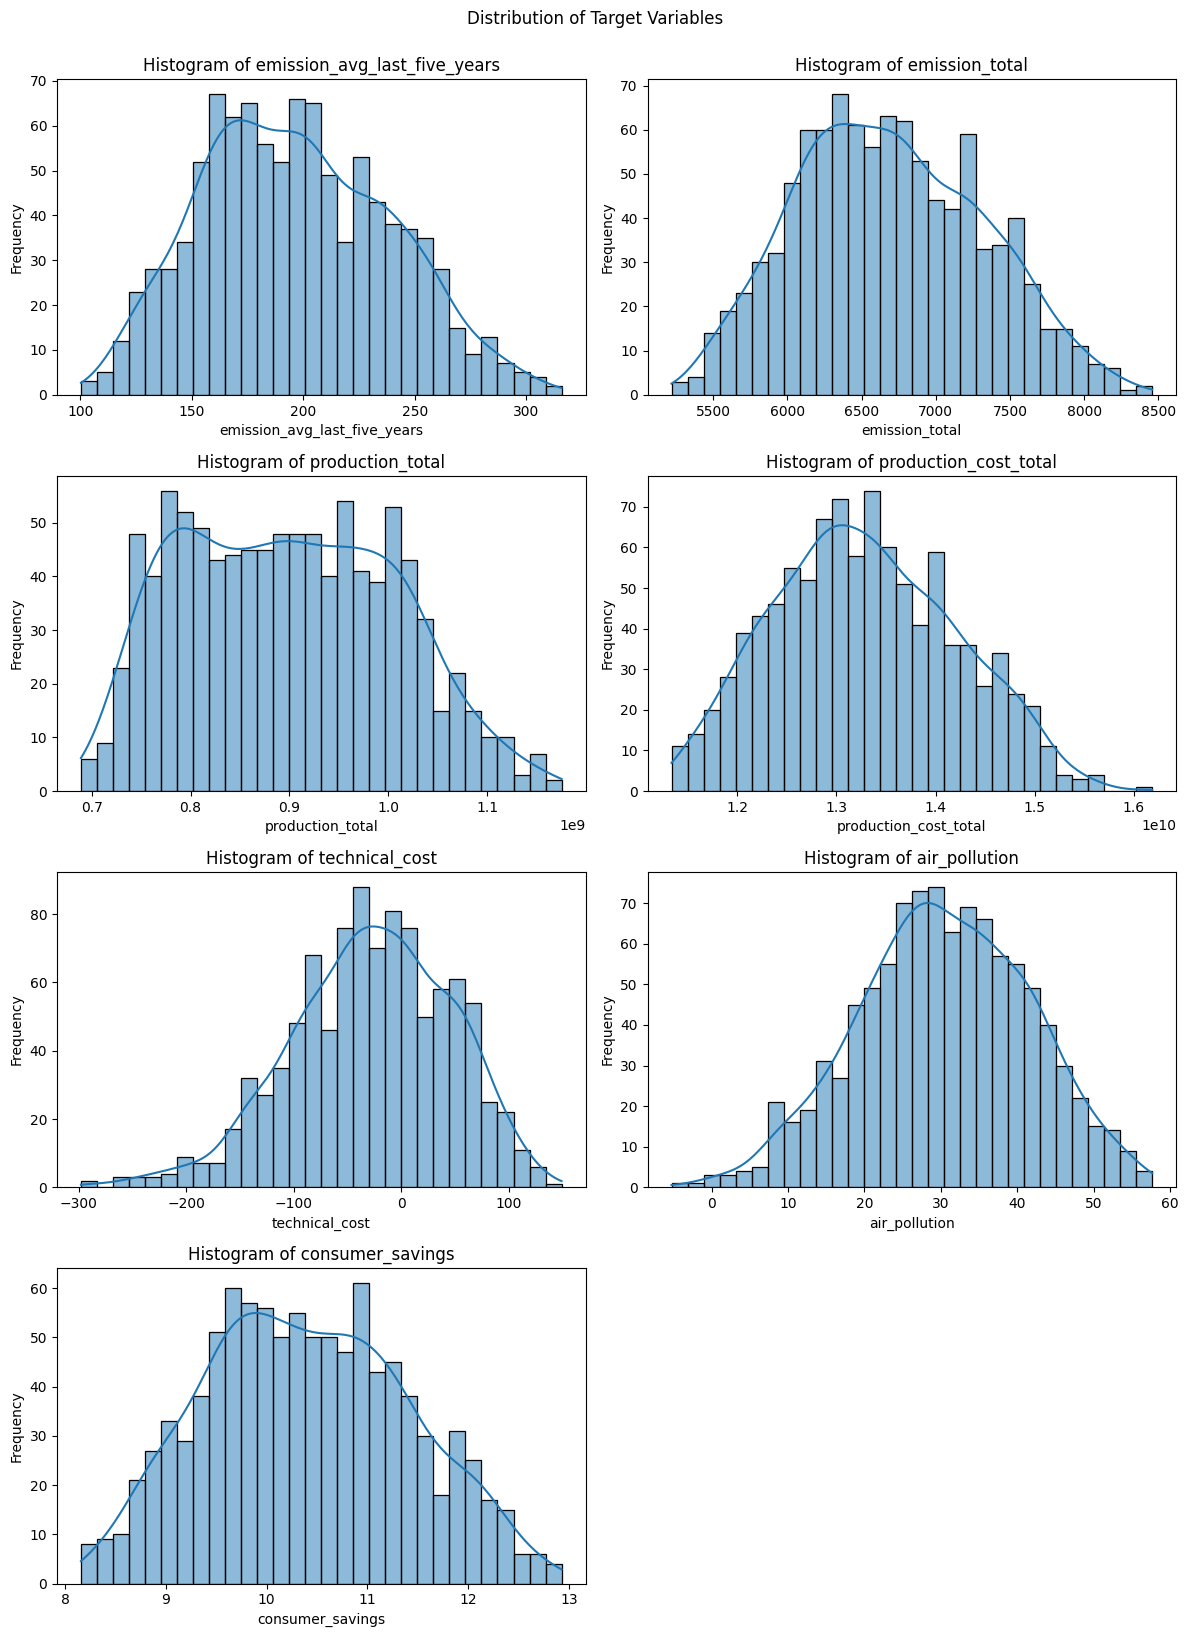

In [8]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [9]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "consumer_savings", exclude_cols=target_cols)
#edau.get_target_var_corr(training_df, "human_health", exclude_cols=target_cols)


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_7_nemomod_en             : 0.7539
group_51_exports_enfu_pj_fuel  : 0.6109
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2017
group_12_frac_inen_energy      : 0.1907
group_32_demscalar_trde        : 0.1207
group_36_frac_trns_fuelmix_road_light : 0.1189


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_7_nemomod_en             : 0.7832
group_51_exports_enfu_pj_fuel  : 0.5448
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2259
group_12_frac_inen_energy      : 0.2008
group_36_frac_trns_fuelmix_road_light : 0.1450
group_32_demscalar_trde        : 0.1328


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
group_12_frac_inen_energy      : 0.9264
group_11_scalar_

In [12]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [10]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'production_cost_total': 0.1, 'technical_cost': 0.81, 'air_pollution': 0.3}


## Data Cleaning

In [11]:
dcu = DataCleaningUtils()

In [12]:
training_df.shape

(990, 65)

In [16]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [17]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [13]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (990, 65)
Shape after removing outliers: (979, 65)


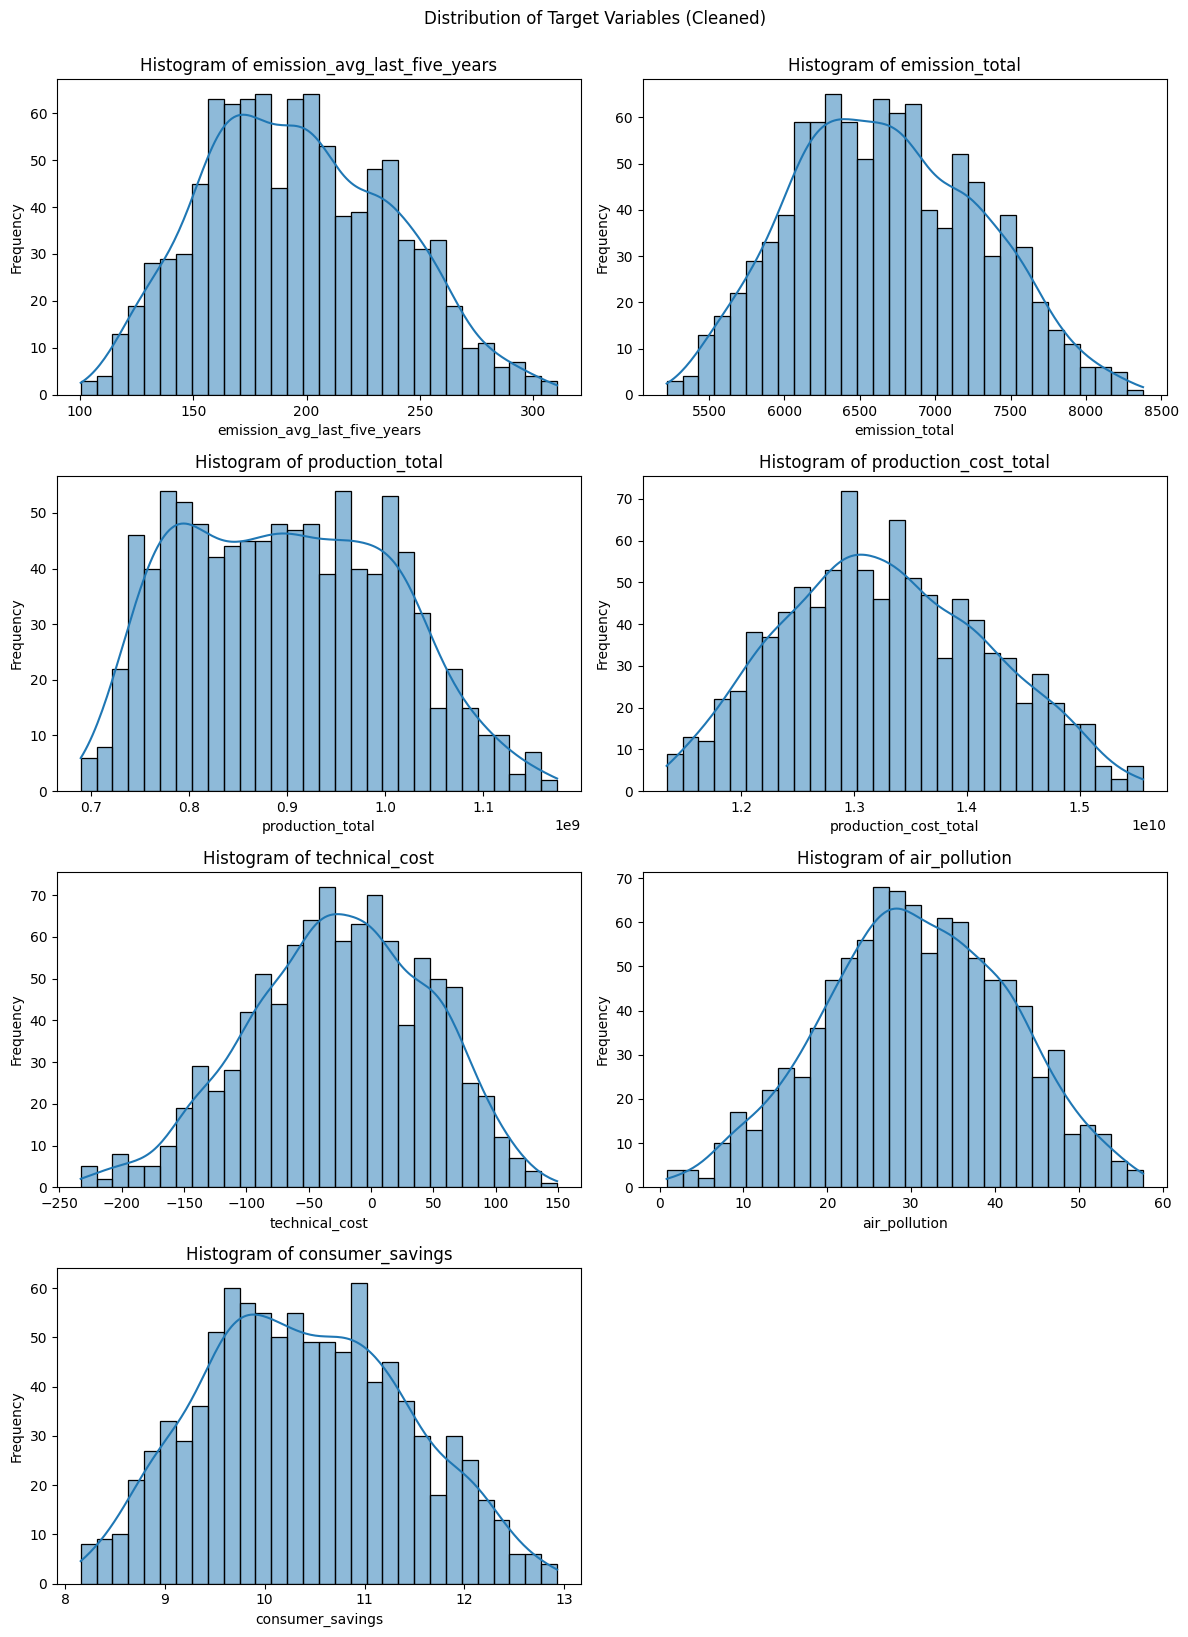

In [14]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [15]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [16]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "consumer_savings", exclude_cols=target_cols)
#edau.get_target_var_corr(training_df, "human_health", exclude_cols=target_cols)


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_7_nemomod_en             : 0.7539
group_51_exports_enfu_pj_fuel  : 0.6109
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2017
group_12_frac_inen_energy      : 0.1907
group_32_demscalar_trde        : 0.1207
group_36_frac_trns_fuelmix_road_light : 0.1189


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_7_nemomod_en             : 0.7832
group_51_exports_enfu_pj_fuel  : 0.5448
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2259
group_12_frac_inen_energy      : 0.2008
group_36_frac_trns_fuelmix_road_light : 0.1450
group_32_demscalar_trde        : 0.1328


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
group_12_frac_inen_energy      : 0.9264
group_11_scalar_

In [17]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings
count,979.000000,979.000000,9.790000e+02,9.790000e+02,979.000000,979.000000,979.000000
mean,196.064580,6678.205716,8.993144e+08,1.327741e+10,-25.933067,30.616921,10.396575
std,41.611502,618.338876,1.062268e+08,9.062148e+08,71.138877,10.969423,1.008716
min,100.337873,5218.478784,6.890388e+08,1.133626e+10,-232.969403,0.829986,8.157804
25%,164.489069,6205.812994,8.089990e+08,1.260344e+10,-76.343621,22.972546,9.630274
50%,193.958571,6642.872768,8.964500e+08,1.323113e+10,-23.834122,30.490361,10.329147
75%,227.279283,7144.414883,9.829583e+08,1.393971e+10,27.072861,38.571579,11.143639
max,310.576044,8378.311602,1.175447e+09,1.556307e+10,149.208209,57.675623,12.928169


In [24]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [25]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [26]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [27]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [28]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}

=== XGB ===
emission_avg_last_five_years  
  Train → MAE: 1.3770, RMSE: 1.7523, R²: 0.9983, SMAPE: 0.7%
   Test → MAE: 5.7672, RMSE: 7.1886, R²: 0.9660, SMAPE: 3.1%
emission_total                
  Train → MAE: 20.7421, RMSE: 26.3436, R²: 0.9982, SMAPE: 0.3%
   Test → MAE: 81.8974, RMSE: 103.2207, R²: 0.9685, SMAPE: 1.2%
production_total              
  Train → MAE: 2006988.7425, RMSE: 2622768.1013, R²: 0.9994, SMAPE: 0.2%
   Test → MAE: 8154761.8764, RMSE: 10762583.2368, R²: 0.9892, SMAPE: 0.9%
production_cost_total         
  Train → MAE: 21121606.6902, RMSE: 26906561.8698, R²: 0.9991, SMAPE: 0.2%
   Test → MAE: 72331174.9420, RMSE: 93271185.6639, R²: 0.9879, SMAPE: 0.5%
technical_cost                
  Train → MAE: 3.1870, RMSE: 4.0915, R²: 0.9968, SMAPE: 14

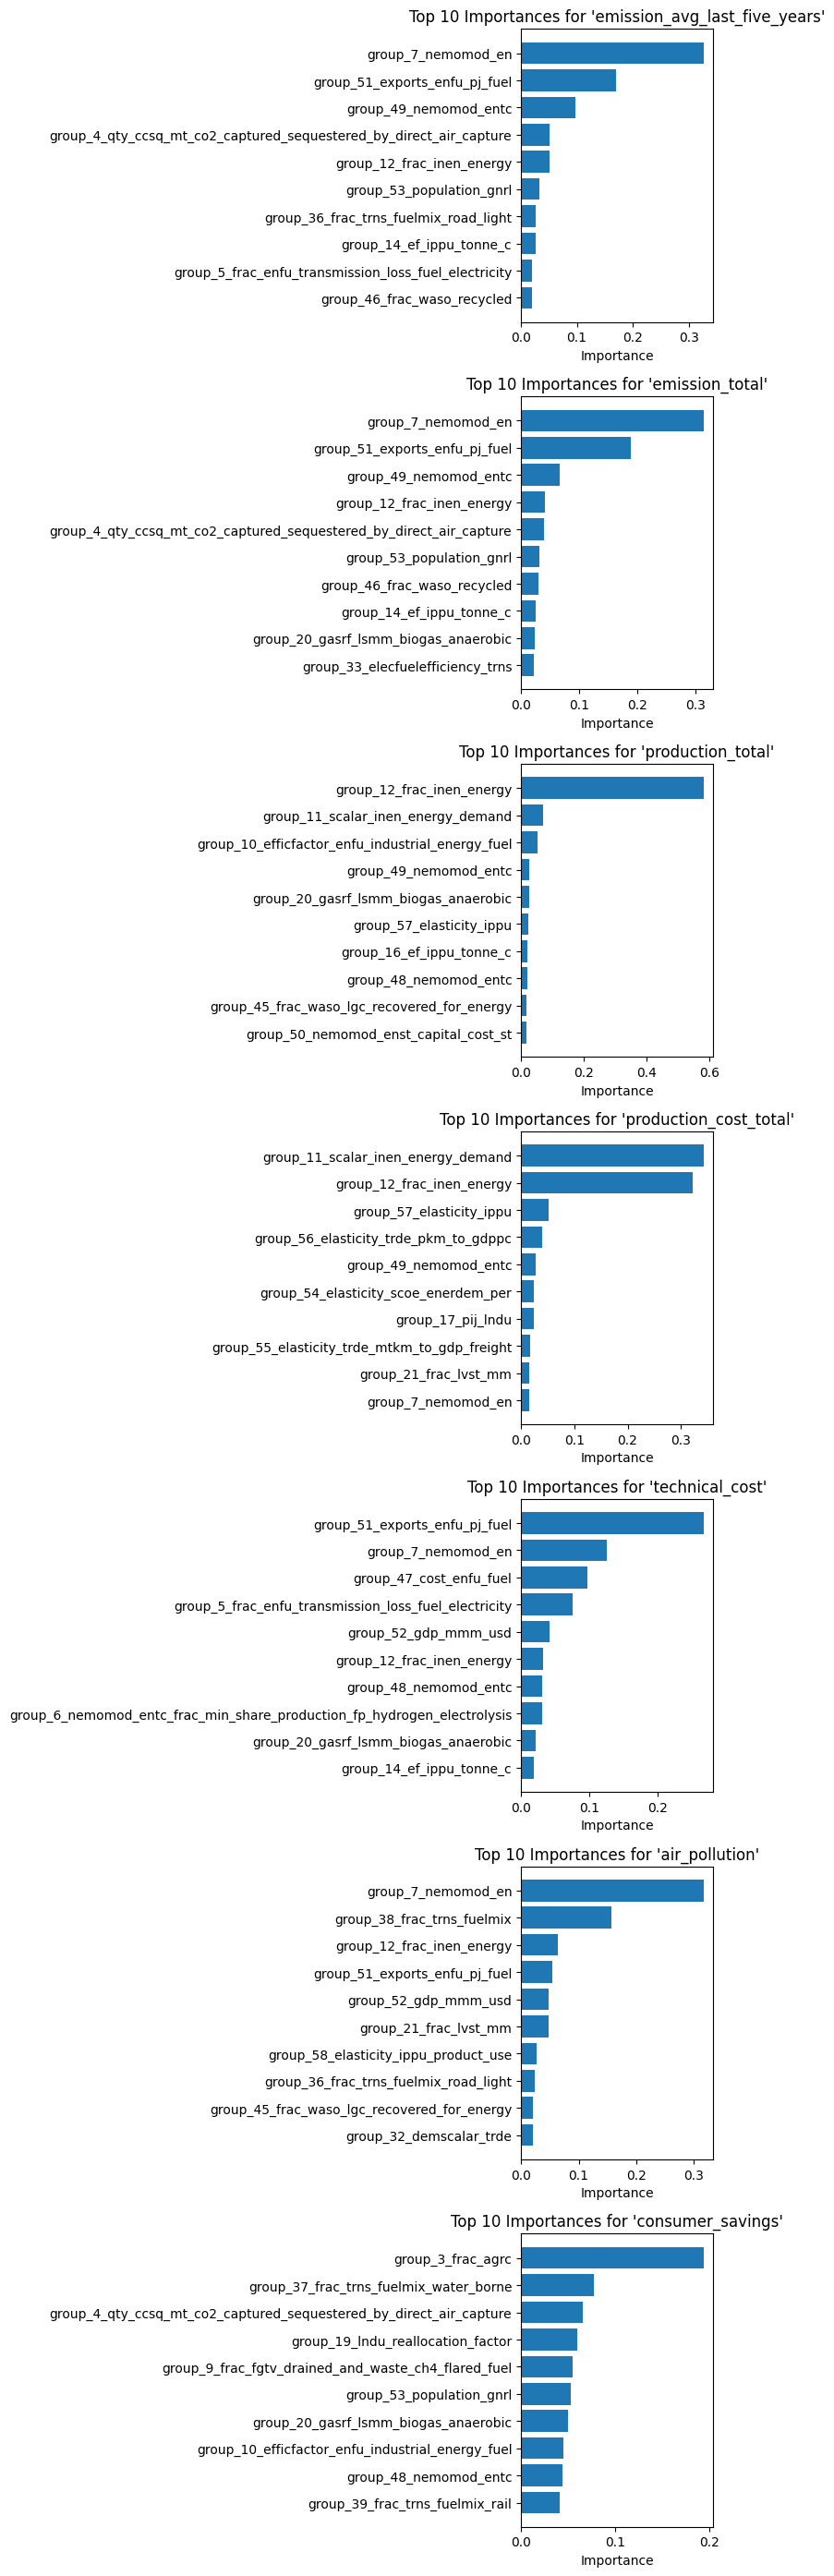

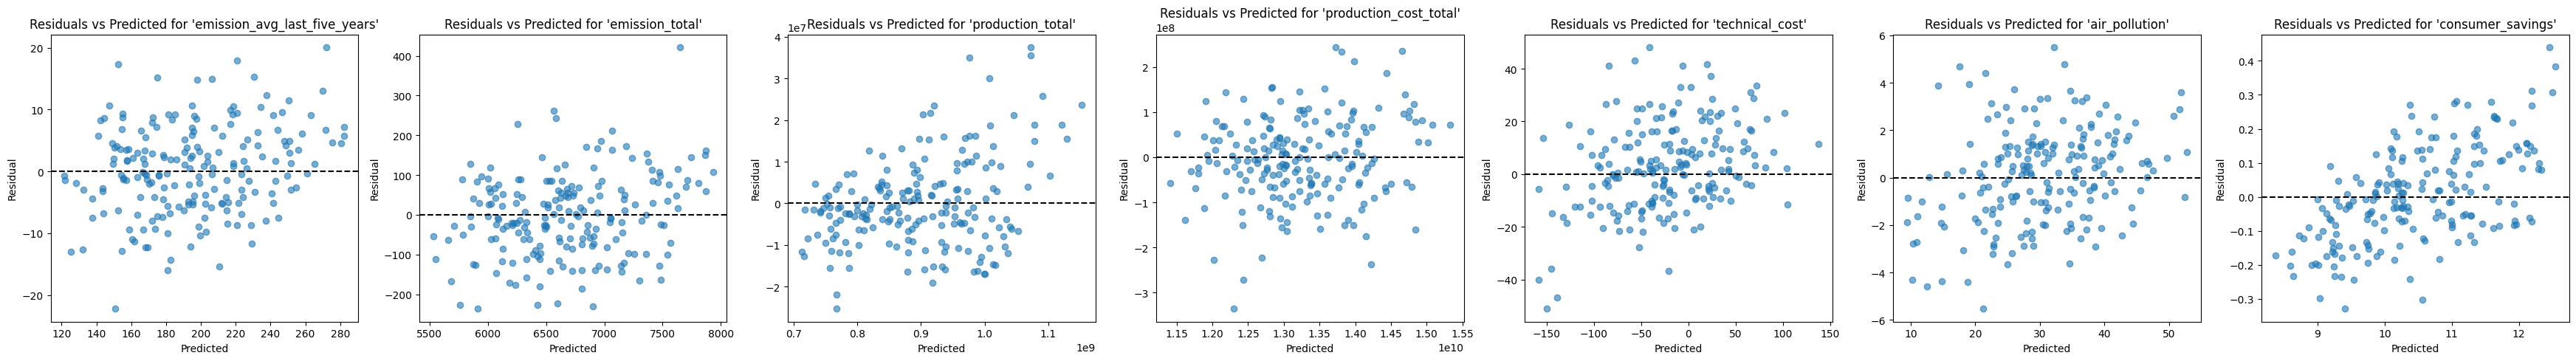

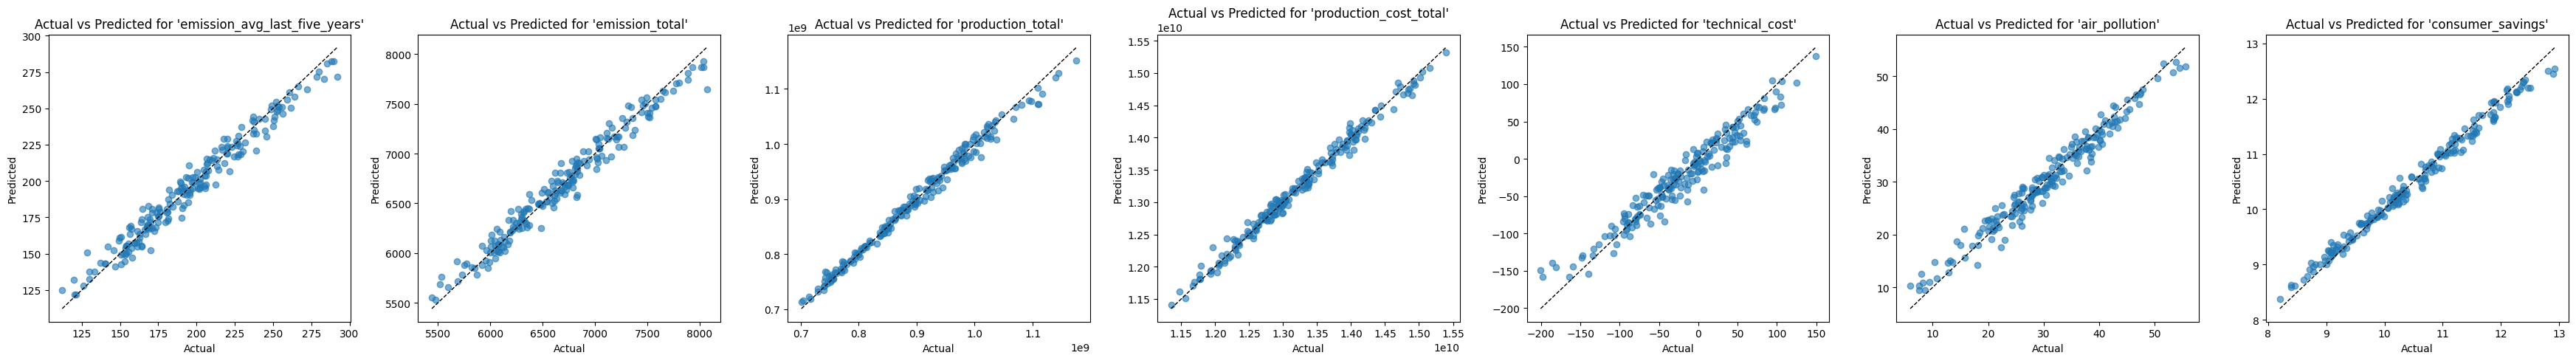

In [18]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=target_cols)
mulp.run(tune=True, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [19]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings
0,0.354682,0.681300,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.681412,0.199758,0.969220,198.512688,6648.349151,9.944817e+08,1.209662e+10,72.057617,39.031999,10.909213
1,0.023662,0.659807,0.066549,0.350365,0.536160,0.040042,0.101776,0.683933,0.343598,0.707471,...,0.000798,0.725034,0.902345,228.001674,7129.331813,7.733990e+08,1.427672e+10,-13.958464,20.164441,9.862279
2,0.414641,0.092022,0.227137,0.020454,0.832906,0.293800,0.601890,0.263913,0.878754,0.211035,...,0.575067,0.208350,0.175365,182.853198,6396.992675,7.860210e+08,1.501253e+10,35.944249,35.268119,9.606087
3,0.307337,0.204967,0.050181,0.805452,0.558369,0.506111,0.974177,0.923617,0.904693,0.923400,...,0.506764,0.227383,0.113647,132.272042,5771.905648,7.332484e+08,1.419782e+10,-5.660414,34.670174,9.917888
4,0.800355,0.458285,0.101171,0.738594,0.254548,0.034029,0.673997,0.851671,0.418375,0.308669,...,0.362234,0.947292,0.764492,173.059694,6393.870401,9.001498e+08,1.355211e+10,-14.126208,32.423383,9.132959


In [20]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(target_cols)
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.354682,0.6813,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.115895,0.456909,0.389376,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.96922


In [21]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    196.794678     6660.618164       995488832.0   

   production_cost_total  technical_cost  air_pollution  consumer_savings  
0           1.209011e+10       64.268028      39.068325         11.006552  
Original values:
emission_avg_last_five_years    1.985127e+02
emission_total                  6.648349e+03
production_total                9.944817e+08
production_cost_total           1.209662e+10
technical_cost                  7.205762e+01
air_pollution                   3.903200e+01
consumer_savings                1.090921e+01
Name: 0, dtype: float64


In [22]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.3_without_health.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.3_without_health.pkl to e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\trained_models\xgb_pipeline_5.3_without_health.pkl.


In [23]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [24]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    196.794678     6660.618164       995488832.0   

   production_cost_total  technical_cost  air_pollution  consumer_savings  
0           1.209011e+10       64.268028      39.068325         11.006552  


In [25]:
from pathlib import Path
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)
mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.3_without_health_X_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.3_without_health_y_test.parquet")


In [ ]:
training_df_cleaned.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.3_without_health_training_df_cleaned.parquet")